# Hamming Nets — does any metric distinguish *memorizing* from *generalizing*?

We score the eight **Hamming Nets** (4 datasets × {`real` = generalizing,
`random` = memorizing}) with all three metric batteries
(`metrics`, `nx_metrics`, `label_metrics`) and ask, per metric, whether
**real** and **random** separate.

Design: only 4 datasets, so the regime is *paired within a dataset*
(`Δ = real − random`). The evidence is therefore **sign agreement across
datasets** (a sign test), not a per-metric magnitude. Two readouts:

1. a per-metric **two-sided sign-test p-value** (binomial, p₀ = ½), and
2. a **real-vs-random scatter** of the top-ranked metrics (one point per
   dataset; off-diagonal = the regimes separate).

> ⚠️ With n = 4 paired datasets the smallest attainable two-sided sign-test
> p-value is `2·(½)⁴ = 0.125`, so **no single metric can reach p < 0.05** here.
> A 4/4 sign agreement is the strongest available evidence; several
> independent metrics agreeing the same way is what matters.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import binomtest

# Make the project package importable from notebooks/.
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.stn.build import STN
from src.stn.metrics import metrics_table
from src.stn.nx_metrics import nx_measures_table, paired_study
from src.stn.label_metrics import label_measures_table

sns.set_context("notebook")
HAMMING = ROOT / "results" / "stn" / "hamming"
stns = [STN.load(p) for p in sorted(HAMMING.glob("*.pkl"))]
print(f"{len(stns)} Hamming Nets:",
      ", ".join(f"{s.condition[0]}/{s.condition[1]}" for s in stns))

8 Hamming Nets: Bioresponse/random, Bioresponse/real, CIFAR_10/random, CIFAR_10/real, Fashion-MNIST/random, Fashion-MNIST/real, mnist_784/random, mnist_784/real


## 1. Assemble all metrics into one table

The three batteries share no metric names (only the `dataset` / `label_type`
keys), so we merge them column-wise into one wide table of every metric for the
eight nets. `metrics_table` also carries a `model` constant we drop.

In [2]:
base = metrics_table(stns).drop(columns=["model"])
nxm = nx_measures_table(stns)
lab = label_measures_table(stns)

KEYS = ["dataset", "label_type"]
measures = base.merge(nxm, on=KEYS).merge(lab, on=KEYS)
# Drop all-constant / all-NaN metric columns — they cannot discriminate.
metric_cols = [m for m in measures.columns if m not in KEYS]
keep = [m for m in metric_cols
        if measures[m].nunique(dropna=True) > 1]
dropped = sorted(set(metric_cols) - set(keep))
measures = measures[KEYS + keep]
print(f"{len(keep)} non-constant metrics kept; dropped {len(dropped)} constant/NaN:")
print("  ", ", ".join(dropped))
measures

63 non-constant metrics kept; dropped 13 constant/NaN:
   edge_connectivity_lcc, flow_hierarchy, frac_equal, is_dag, largest_wcc_frac, n_isolates, n_weakly_conn, node_connectivity_lcc, num_best, num_comp, reciprocity, strength, term_frac_reachable


,dataset,label_type,num_nodes,num_ends,num_edges,impr_edges,plength,npaths,n_nodes,n_edges,...,dirichlet_energy_norm,fdc_terminal,conductance_terminal,modularity_role,frac_improving,frac_worsening,num_terminal,best_fitness,term_mean_dist,term_mean_dist_norm
0,Bioresponse,random,26,0,32,1.00,6.42,12,26,32,...,0.168548,-0.982160,1.000000,0.092285,1.000000,0.000000,1,0.868444,NaN,NaN
1,Bioresponse,real,27,0,26,0.92,8.38,13,27,26,...,0.230261,-0.964177,1.000000,0.093935,0.923077,0.076923,1,0.933333,NaN,NaN
2,CIFAR_10,random,557,13,556,0.93,26.80,20,557,556,...,0.082832,-0.914842,0.695652,0.019622,0.931655,0.068345,14,0.993648,2.86,0.11
3,CIFAR_10,real,176,11,220,0.89,15.00,20,176,220,...,0.352670,-0.959049,0.641026,0.035733,0.886364,0.113636,12,0.921519,2.50,0.35
4,Fashion-MNIST,random,785,14,784,0.86,37.60,20,785,784,...,0.076864,-0.938564,0.791667,0.009775,0.858418,0.141582,15,0.989444,4.27,0.12
5,Fashion-MNIST,real,10,0,9,1.00,3.00,7,10,9,...,1.628220,-0.977306,1.000000,-0.351852,1.000000,0.000000,1,0.815111,NaN,NaN
6,mnist_784,random,541,18,556,0.90,23.07,15,541,556,...,0.088531,-0.945147,0.928571,0.021945,0.897482,0.102518,19,0.987937,5.37,0.30
7,mnist_784,real,25,0,24,1.00,3.00,20,25,24,...,1.125111,-0.936029,1.000000,-0.365451,1.000000,0.000000,1,0.841175,NaN,NaN


## 2. Per-metric sign test (paired real − random)

For each metric we take the paired difference `Δ = real − random` over the
datasets that have both regimes, count how many datasets give `real > random`
vs `real < random`, and run a **two-sided binomial sign test** (`p₀ = ½`).
We report it alongside the existing `paired_study` summary (mean Δ, direction,
sign consistency, and the standardized paired effect `dz = mean(Δ)/std(Δ)`).

In [3]:
def sign_test_table(table: pd.DataFrame, pos="real", neg="random") -> pd.DataFrame:
    '''paired_study augmented with explicit up/down counts and a sign-test p-value.'''
    real = table[table["label_type"] == pos].set_index("dataset")
    rand = table[table["label_type"] == neg].set_index("dataset")
    common = real.index.intersection(rand.index)
    rows = []
    for m in [c for c in table.columns if c not in ("dataset", "label_type")]:
        diff = (real.loc[common, m] - rand.loc[common, m]).dropna()
        if diff.empty:
            continue
        npos, nneg, n = int((diff > 0).sum()), int((diff < 0).sum()), len(diff)
        n_eff = npos + nneg  # ties carry no sign and are excluded from the test
        p = (binomtest(max(npos, nneg), n_eff, 0.5, alternative="two-sided").pvalue
             if n_eff else np.nan)
        sd = diff.std(ddof=1)
        rows.append({
            "metric": m, "n_pairs": n, "real>rand": npos, "real<rand": nneg,
            "mean_diff": diff.mean(),
            "direction": "real>random" if npos >= nneg else "real<random",
            "sign_consistency": max(npos, nneg) / n_eff if n_eff else np.nan,
            "effect_dz": diff.mean() / sd if sd and sd > 0 else np.nan,
            "p_sign": p,
        })
    res = pd.DataFrame(rows)
    res["abs_dz"] = res["effect_dz"].abs()
    res = (res.sort_values(["sign_consistency", "abs_dz"], ascending=False)
              .drop(columns="abs_dz").reset_index(drop=True))
    return res

ranked = sign_test_table(measures)
with pd.option_context("display.max_rows", None, "display.float_format", "{:.3f}".format):
    display(ranked)

/home/agudeloacosta/HOMEdev/AE_paper/.venv/lib/python3.11/site-packages/pandas/core/nanops.py:1027: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


,metric,n_pairs,real>rand,real<rand,mean_diff,direction,sign_consistency,effect_dz,p_sign
0,moran_I,4,0,4,-0.532,real<random,1.000,-1.505,0.125
1,num_edges,4,0,4,-412.250,real<random,1.000,-1.269,0.125
2,n_edges,4,0,4,-412.250,real<random,1.000,-1.269,0.125
3,harmonic_max,4,0,4,-42.128,real<random,1.000,-1.215,0.125
4,assort_fitness,4,0,4,-0.075,real<random,1.000,-1.110,0.125
5,geary_C,4,4,0,0.339,real>random,1.000,1.092,0.125
6,avg_neighbor_degree_max,4,0,4,-8.375,real<random,1.000,-1.070,0.125
7,dirichlet_energy_norm,4,4,0,0.730,real>random,1.000,1.058,0.125
8,max_degree,4,0,3,-14.000,real<random,1.000,-1.042,0.250
9,num_ends,4,0,3,-8.500,real<random,1.000,-0.960,0.250


### The discriminating metrics

Everything with **4/4 sign consistency** (`p_sign = 0.125`, the floor at n = 4)
is a candidate discriminator. We keep those with a defined effect size and a
finite spread to plot below.

In [4]:
TOP_N = 10
top = ranked[(ranked["sign_consistency"] == 1.0) & ranked["effect_dz"].notna()].copy()
top = top.reindex(top["effect_dz"].abs().sort_values(ascending=False).index)
top_metrics = top["metric"].head(TOP_N).tolist()
print("Top discriminators (4/4 sign agreement, |dz| desc):")
for _, r in top.head(TOP_N).iterrows():
    print(f"  {r['metric']:>24s}  {r['direction']:>11s}  dz={r['effect_dz']:+.2f}  p={r['p_sign']:.3f}")

Top discriminators (4/4 sign agreement, |dz| desc):
                   moran_I  real<random  dz=-1.50  p=0.125
                 num_edges  real<random  dz=-1.27  p=0.125
                   n_edges  real<random  dz=-1.27  p=0.125
              harmonic_max  real<random  dz=-1.22  p=0.125
            assort_fitness  real<random  dz=-1.11  p=0.125
                   geary_C  real>random  dz=+1.09  p=0.125
   avg_neighbor_degree_max  real<random  dz=-1.07  p=0.125
     dirichlet_energy_norm  real>random  dz=+1.06  p=0.125
                max_degree  real<random  dz=-1.04  p=0.250
                  num_ends  real<random  dz=-0.96  p=0.250


## 3. Real-vs-random scatter for the top metrics

One point per dataset: **x = random (memorizing)**, **y = real (generalizing)**.
The dashed line is `y = x` (no difference). Points landing consistently on the
*same* side of the diagonal mean the metric separates the two regimes; the
caption gives the sign-test direction and p-value.

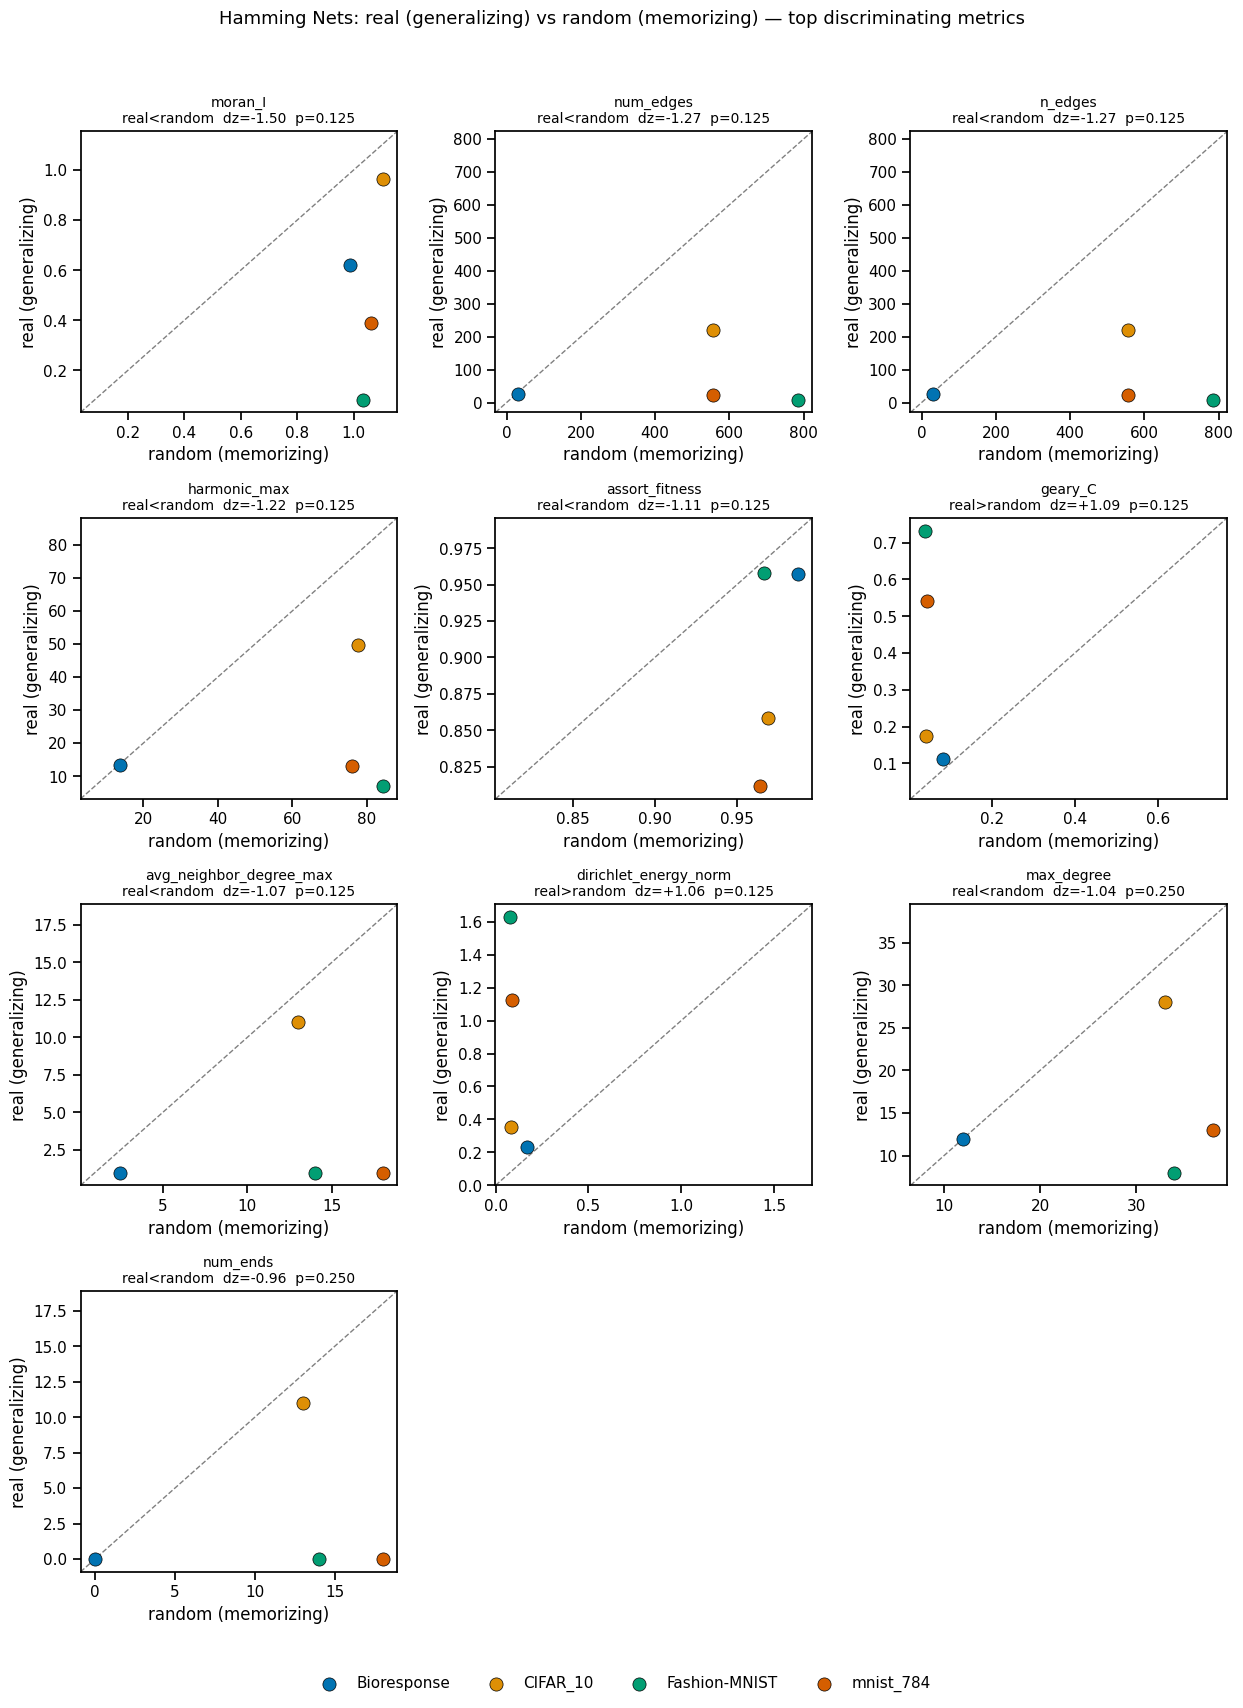

In [5]:
real = measures[measures["label_type"] == "real"].set_index("dataset")
rand = measures[measures["label_type"] == "random"].set_index("dataset")
common = sorted(real.index.intersection(rand.index))
palette = dict(zip(common, sns.color_palette("colorblind", len(common))))

ncols = 3
nrows = int(np.ceil(len(top_metrics) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(4.2 * ncols, 4.0 * nrows))
axes = np.atleast_1d(axes).ravel()

for ax, m in zip(axes, top_metrics):
    info = ranked.set_index("metric").loc[m]
    xs = rand.loc[common, m].astype(float)
    ys = real.loc[common, m].astype(float)
    finite = xs.notna() & ys.notna()
    lo = float(np.nanmin([xs[finite].min(), ys[finite].min()]))
    hi = float(np.nanmax([xs[finite].max(), ys[finite].max()]))
    pad = 0.05 * (hi - lo or 1.0)
    ax.plot([lo - pad, hi + pad], [lo - pad, hi + pad], "--", color="grey", lw=1, zorder=0)
    for ds in common:
        if finite[ds]:
            ax.scatter(xs[ds], ys[ds], color=palette[ds], s=90,
                       edgecolor="k", linewidth=0.5, label=ds, zorder=3)
    ax.set_xlim(lo - pad, hi + pad); ax.set_ylim(lo - pad, hi + pad)
    ax.set_xlabel("random (memorizing)"); ax.set_ylabel("real (generalizing)")
    ax.set_title(f"{m}\n{info['direction']}  dz={info['effect_dz']:+.2f}  p={info['p_sign']:.3f}",
                 fontsize=10)

for ax in axes[len(top_metrics):]:
    ax.set_visible(False)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=len(common),
           bbox_to_anchor=(0.5, -0.04), frameon=False)
fig.suptitle("Hamming Nets: real (generalizing) vs random (memorizing) — top discriminating metrics",
             y=1.02, fontsize=13)
fig.tight_layout()
plt.show()

## 4. Paired-difference (slope) view

The same evidence as a paired plot: each line joins a dataset's random → real
value. A bundle of lines tilting the same way = consistent regime effect.
Metrics are z-scored across the eight nets so they share one axis.

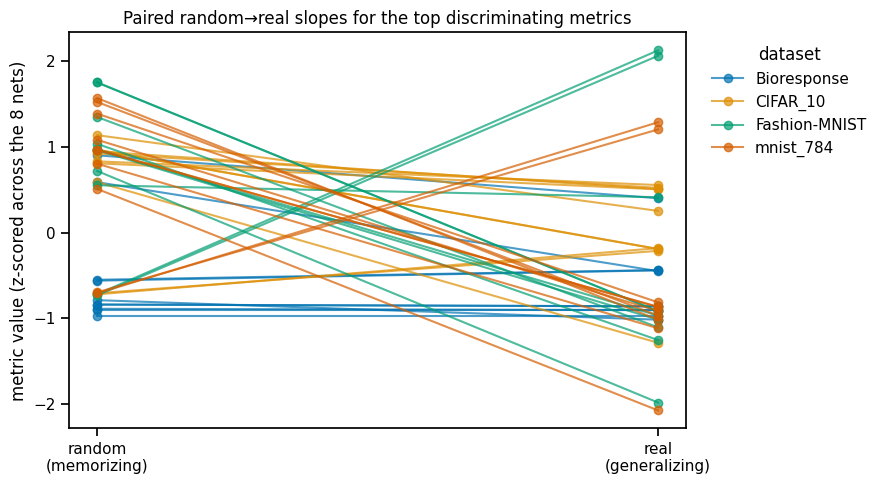

In [6]:
z = measures.copy()
for m in top_metrics:
    col = z[m].astype(float)
    z[m] = (col - col.mean()) / (col.std(ddof=0) or 1.0)

long = z.melt(id_vars=["dataset", "label_type"], value_vars=top_metrics,
              var_name="metric", value_name="zval")
fig, ax = plt.subplots(figsize=(9, 5))
order = {"random": 0, "real": 1}
for (ds, m), g in long.groupby(["dataset", "metric"]):
    g = g.sort_values("label_type", key=lambda s: s.map(order))
    ax.plot([0, 1], g["zval"].values, "-o", color=palette[ds], alpha=0.7,
            label=ds if m == top_metrics[0] else None)
ax.set_xticks([0, 1]); ax.set_xticklabels(["random\n(memorizing)", "real\n(generalizing)"])
ax.set_ylabel("metric value (z-scored across the 8 nets)")
ax.set_title("Paired random→real slopes for the top discriminating metrics")
ax.legend(title="dataset", bbox_to_anchor=(1.02, 1), loc="upper left", frameon=False)
fig.tight_layout()
plt.show()

## 5. Takeaways

- **Several metrics separate the regimes with full (4/4) sign agreement** — the
  best n = 4 can offer (sign-test `p = 0.125`; nothing reaches p < 0.05, by
  construction). Leading the list are the **size-normalized smoothness-of-
  accuracy** metrics — `moran_I` (real < random), `geary_C` and
  `dirichlet_energy_norm` (real > random), and `assort_fitness` (real < random)
  — plus raw graph size (`n_edges`) on the larger multiclass datasets.
- **Mechanism.** *Memorizing* (random labels) = a long, smooth crawl through many
  distinct prediction vectors (large STN, high accuracy autocorrelation).
  *Generalizing* (real labels) = a short, abrupt funnel to a shared decision
  function (small STN, low autocorrelation, large per-edge accuracy jumps).
- **Caveat.** `Bioresponse` (small binary task) is the recurring outlier and is
  what knocks raw-size metrics below 4/4; the **normalized** smoothness metrics
  survive it, so they are the more transportable discriminators.